# Spam Letters Classification

Import needed packages

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, ConfusionMatrixDisplay


from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os
import email

# Html remover
from bs4 import BeautifulSoup

# Regexp
import re

# For stemming
import nltk

Function to get csv data as pandas `DataFrame`

In [2]:
EMAILS_DATASETS_PATH = os.path.join("datasets", "spam-emails")

def get_data(filename: str) -> pd.DataFrame:
    full_path = os.path.join(EMAILS_DATASETS_PATH, filename)
    return pd.read_csv(full_path)

emails_data = get_data("email_origin.csv")

As we can see, there is 1897 spam adn 4151 non spam emails.

In [3]:
emails_data.info()
emails_data["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6048 entries, 0 to 6047
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   6048 non-null   int64 
 1   origin  6048 non-null   object
dtypes: int64(1), object(1)
memory usage: 94.6+ KB


label
0    4151
1    1897
Name: count, dtype: int64

Let's split this dataset into train and test sets.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(emails_data, emails_data["label"]):
    train, test = emails_data.iloc[train_idx], emails_data.iloc[test_idx]

Now, we need to dig into email structure and think how we can prepare and extract more data.

In [5]:
train["origin"].iloc[0]

'Return-Path: <ilug-admin@linux.ie>\r\nDelivered-To: zzzz@localhost.netnoteinc.com\r\nReceived: from localhost (localhost [127.0.0.1])\r\n\tby phobos.labs.netnoteinc.com (Postfix) with ESMTP id C2E7C47C74\r\n\tfor <zzzz@localhost>; Mon,  2 Sep 2002 07:42:03 -0400 (EDT)\r\nReceived: from phobos [127.0.0.1]\r\n\tby localhost with IMAP (fetchmail-5.9.0)\r\n\tfor zzzz@localhost (single-drop); Mon, 02 Sep 2002 12:42:03 +0100 (IST)\r\nReceived: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by\r\n    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g827VJZ23920 for\r\n    <zzzz-ilug@spamassassin.taint.org>; Mon, 2 Sep 2002 08:31:19 +0100\r\nReceived: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org\r\n    (8.9.3/8.9.3) with ESMTP id IAA22561; Mon, 2 Sep 2002 08:30:44 +0100\r\nReceived: from moe.jinny.ie (homer.jinny.ie [193.120.171.3]) by\r\n    lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id IAA22526 for <ilug@linux.ie>;\r\n    Mon, 2 Sep 2002 08:30:36 +0100\r\nX-Authent

Looks like default email structure, we can work with it using `email` library.

In [6]:
for i, origin in enumerate(train["origin"].iloc[:20]):
    print(f"№{i} =========")
    message = email.message_from_string(origin)
    for part in message.walk():
        print(part.get_content_type())
    print()

№0 =========
text/plain

№1 =========
text/plain

№2 =========
text/plain

№3 =========
text/plain

№4 =========
text/plain

№5 =========
text/plain

№6 =========
text/html

№7 =========
text/plain

№8 =========
text/html

№9 =========
text/plain

№10 =========
multipart/alternative
text/plain
text/html

№11 =========
text/plain

№12 =========
text/plain

№13 =========
text/plain

№14 =========
text/plain

№15 =========
text/plain

№16 =========
text/plain

№17 =========
text/plain

№18 =========
text/plain

№19 =========
text/html



Function that extracts message body and converts it to text. `Email` library documentation -> https://docs.python.org/3/library/email.compat32-message.html#email.message.Message.get_payload

In [7]:
def get_email_text(message: email.message.Message) -> str:
    text = None
    html = None

    for part in message.walk():
        content_type = part.get_content_type()

        if content_type == "text/plain":
            charset = part.get_charset() or "utf-8"
            text = part.get_payload(decode=True).decode(charset, errors="ignore")
            break
        elif content_type == "text/html":
            charset = part.get_charset() or "utf-8"
            html = part.get_payload(decode=True).decode(charset, errors="ignore")

    if text:
        return text
    elif html:
        soup = BeautifulSoup(html)
        return soup.get_text(separator=" ", strip=html)

    return ""


In [8]:
def clear_email_text(text: str, to_lowercase: bool = True, to_strip: bool = True, remove_punctuation: bool = True, remove_URL_lefts: bool = True) -> str:
    text = str.strip(text) if to_strip else text
    text = str.lower(text) if to_lowercase else text
    text = re.sub(r'[^\w\s]', "", text) if remove_punctuation else text
    text = re.sub(r'[^ ]*http[^ ]*', "", text) if remove_URL_lefts else text

    return text

Function that performs stemming on each word in the sentence.

In [9]:
def trim_words_endings(message_text: str) -> str:
    words = message_text.split()

    ps = nltk.stem.PorterStemmer()

    stemmed_words = [ps.stem(word) for word in words]

    return  " ".join(stemmed_words)

Function that adds new `text` column to each email entry, and returns copy of the dataset.

In [10]:
def extract_email_text(dataset: pd.DataFrame) -> pd.DataFrame:
    texts = []
    for origin in dataset["origin"]:
        message = email.message_from_string(origin)
        email_text = get_email_text(message)
        texts.append(email_text)

    dataset_copy = dataset.copy()
    dataset_copy["text"] = texts

    return dataset_copy

In [11]:
emails_data_text = extract_email_text(emails_data[:3])
emails_data_text.head()

,label,origin,text
0,0,Return-Path: <fork-admin@xent.com>\r\nDelivere...,\r\nme:\r\n> >Spam is *the* tool for dissident...
1,0,Return-Path: <bounce-lglinux-2534371@sprocket....,20020709 Lockergnome Penguin Shell 07.09.2002 ...
2,0,Return-Path: <ilug-admin@linux.ie>\r\nDelivere...,"On Wednesday 31 July 2002 12:02, Satelle, Stev..."


Custom Sklearn transformers to:
- Extract email texts
- Clear them
- Transform them into a sparse matrix that represents sentence vector

In [12]:
class TextExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        X_copy = X.copy()

        extracted_texts = [get_email_text(email.message_from_string(origin)) for origin in X["origin"]]
        X_copy["text"] = extracted_texts

        return X_copy

class ClearTextTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, to_lowercase: bool = True, to_strip: bool = True, remove_punctuation: bool = True, remove_URL_lefts: bool = True):
        self.to_strip = to_strip
        self.to_lowercase = to_lowercase
        self.remove_punctuation = remove_punctuation
        self.remove_URL_lefts = remove_URL_lefts

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        X_copy = X.copy()

        X_copy["text"] = X["text"].map(lambda x: clear_email_text(x, self.to_lowercase, self.to_strip, self.remove_punctuation, self.remove_URL_lefts))

        return X_copy

class StemWordsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        X_copy = X.copy()

        X_copy["text"] = X["text"].map(lambda x: trim_words_endings(x))

        return X_copy

class VectorizeEmailTextTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.vectorizer = CountVectorizer()

    def fit(self, X, y=None):
        self.vectorizer.fit(X["text"])
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.vectorizer.transform(X["text"])


Create Sklearn preparation pipeline.

In [13]:
preparation_pipeline = Pipeline([
    ("text_extractor", TextExtractor()),
    ("text_cleaner", ClearTextTransformer()),
    ("words_stemmer", StemWordsTransformer()),
    ("vectorizer", VectorizeEmailTextTransformer()),
])

Create X and y of both train and test datasets.

> Note! We don't call `fit_transform` on a test dataset!

In [14]:
X_train, y_train = preparation_pipeline.fit_transform(train), train["label"]
X_test, y_test = preparation_pipeline.transform(test), test["label"]

C:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Train first model and get its accuracy.

Get predictions, predictions scores, data for precision recall trade-off and data for the ROC curve.

In [22]:
linear_svc_clf = LinearSVC()

lsvc_predictions = cross_val_predict(linear_svc_clf, X_train.toarray(), y_train, cv=3, n_jobs=-1)
lsvc_scores = cross_val_predict(linear_svc_clf, X_train.toarray(), y_train, cv=3, method="decision_function", n_jobs=-1)

In [24]:
precisions, recalls, thresholds = precision_recall_curve(y_train, lsvc_scores)
fpr, tpr, thresholds = roc_curve(y_train, lsvc_scores)

In [25]:
def plot_precision_recall_curve(precisions, recalls) -> None:
    plt.plot(recalls, precisions, label="Precision-recall curve", color="blue", linestyle="--")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid()
    plt.legend()

    plt.show()

def plot_roc(fpr, tpr) -> None:
    plt.plot(fpr, tpr, label="Roc curve", color="blue", linestyle="--")
    plt.plot([0, 1], [0, 1], label="Random model")

    plt.xlabel("False Positive Rate")
    plt.ylabel("Tru Positive Rate")
    plt.grid()
    plt.legend()

    plt.show()

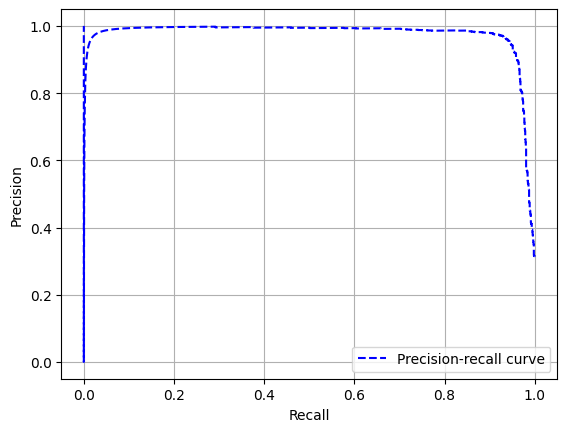

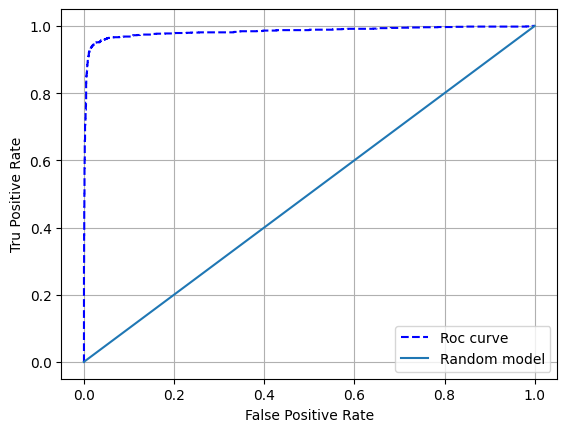

In [26]:
plot_precision_recall_curve(precisions, recalls)
plot_roc(fpr, tpr)

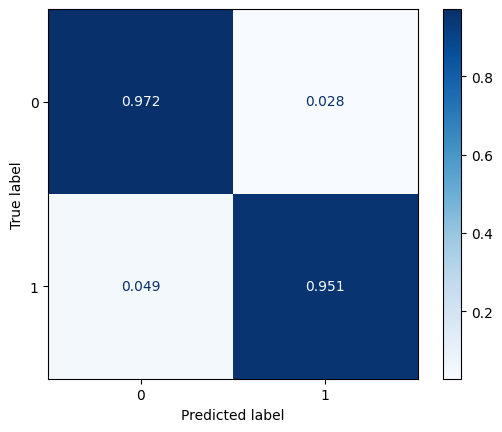

In [29]:
nb_conf_matrix = ConfusionMatrixDisplay.from_predictions(y_train, lsvc_predictions, normalize="true", values_format="0.3f", cmap="Blues")

Now let's try to train DecisionTree classifier ant see if results will get any better

In [30]:
random_forest_clf = RandomForestClassifier()

tree_predictions = cross_val_predict(random_forest_clf, X_train[:3000], y_train[:3000], cv=3, n_jobs=-1)
tree_predictions_proba = cross_val_predict(random_forest_clf, X_train, y_train, cv=3, method="predict_proba", n_jobs=-1)

In [31]:
precisions, recalls, thresholds = precision_recall_curve(y_train, tree_predictions_proba[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, tree_predictions_proba[:, 1])

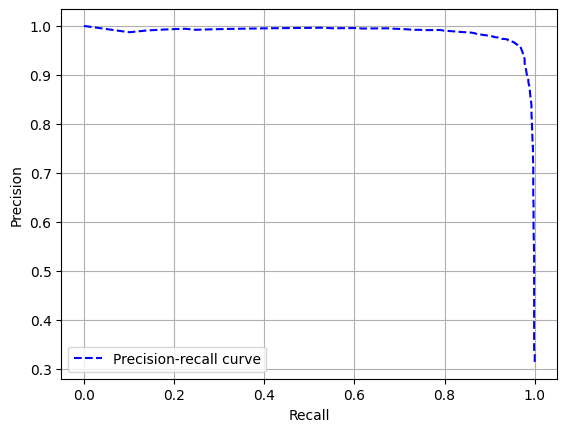

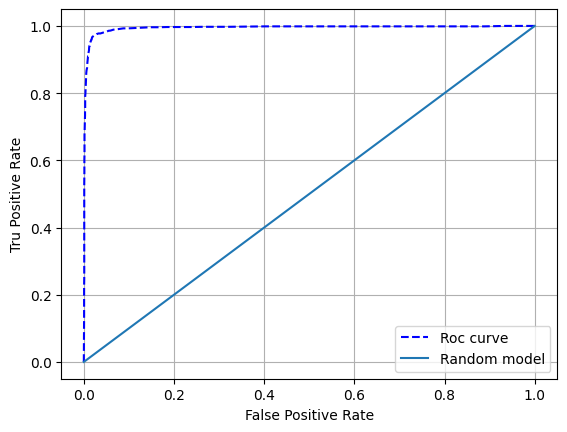

In [32]:
plot_precision_recall_curve(precisions, recalls)
plot_roc(fpr, tpr)

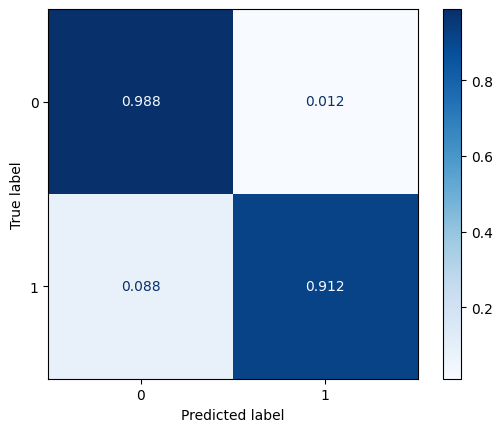

In [33]:
dt_conf_matrix = ConfusionMatrixDisplay.from_predictions(y_train[:3000], tree_predictions, normalize="true", values_format="0.3f", cmap="Blues")

In [40]:
test_svc_accuracies = cross_val_score(linear_svc_clf, X_test, y_test, cv=3, n_jobs=-1, scoring="f1")
test_svc_accuracies

array([0.890625  , 0.92063492, 0.90625   ])